# Amazon Sales Dataset - 고객 세그먼테이션
## RFM 분석

---

## 📋 분석 개요

본 분석은 Amazon Sales Dataset을 활용하여 **RFM(Recency, Frequency, Monetary) 분석**을 수행하고, 고객 가치를 정량적으로 평가하여 **5개 멤버십 등급(Bronze / Silver / Gold / Platinum / Diamond)** 으로 세분화한다. 이를 통해 등급별 특성에 맞는 마케팅 전략을 제시한다.

| 항목 | 내용 |
|------|------|
| 데이터 기간 | 2023-12-29 ~ 2024-12-29 |
| 분석 기준일 | 2024-12-30 |
| 전체 거래 건수 | 20,045건 |
| 전체 고객 수 | 16,479명 |

---

## 🔍 RFM 분석이란?

RFM 분석은 고객의 구매 행동을 3가지 지표로 평가하는 세그먼테이션 기법으로, 마케팅 전략 수립에 널리 활용된다.

| 지표 | 의미 | 측정 방법 |
|------|------|----------|
| **R** (Recency) | 최근성 | 마지막 구매 후 경과 일수 |
| **F** (Frequency) | 빈도 | 총 구매 횟수 |
| **M** (Monetary) | 구매 금액 | 총 구매 금액 |

세 지표를 종합하면 **"최근에 자주, 많이 구매한 고객일수록 높은 가치를 지닌다"** 는 가정 하에 고객을 정량적으로 평가할 수 있다.

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import warnings
from dotenv import load_dotenv
import os

load_dotenv()  # .env 파일 로드

# MySQL 연결
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)


In [2]:
# 데이터 로드
df = pd.read_sql("""
    SELECT * 
    FROM orders_info
    WHERE OrderDate >= DATE_SUB('2024-12-29', INTERVAL 1 YEAR)
    AND OrderDate <= '2024-12-29'
""", engine)

In [3]:
df.head()

,OrderID,OrderDate,CustomerID,ProductID,Category,Brand,Discount,TotalAmount,PaymentMethod
0,ORD0000002,2023-12-30,CUST000178,P00040,Home & Kitchen,UrbanStyle,0.05,259.64,Amazon Pay
1,ORD0000007,2024-09-20,CUST037667,P00030,Clothing,UrbanStyle,0.20,394.81,UPI
2,ORD0000009,2024-06-26,CUST026965,P00031,Sports & Outdoors,Apex,0.00,638.14,Debit Card
3,ORD0000014,2024-01-22,CUST006051,P00040,Home & Kitchen,Apex,0.00,1766.23,Debit Card
4,ORD0000019,2024-08-14,CUST040211,P00033,Electronics,ReadMore,0.00,2968.03,Amazon Pay


In [4]:
# 전체 데이터 건수와 컬럼 수 확인
df.shape

(20045, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20045 entries, 0 to 20044
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        20045 non-null  object        
 1   OrderDate      20045 non-null  datetime64[ns]
 2   CustomerID     20045 non-null  object        
 3   ProductID      20045 non-null  object        
 4   Category       20045 non-null  object        
 5   Brand          20045 non-null  object        
 6   Discount       20045 non-null  float64       
 7   TotalAmount    20045 non-null  float64       
 8   PaymentMethod  20045 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 1.4+ MB


In [6]:
# 고유 고객 수 확인
df['CustomerID'].nunique()

16479

In [7]:
print(f"분석 기간: {df['OrderDate'].min().date()} ~ {df['OrderDate'].max().date()}")

분석 기간: 2023-12-29 ~ 2024-12-29


In [8]:
print(f"기간: {(df['OrderDate'].max() - df['OrderDate'].min()).days}일")

기간: 366일


In [9]:
# 기준일: 데이터의 마지막 날짜 + 1일
reference_date = df['OrderDate'].max() + timedelta(days=1)

print(f"분석 기준일: {reference_date.date()}")

분석 기준일: 2024-12-30


In [10]:
rfm_lifetime = df.groupby('CustomerID').agg({
    'OrderDate': lambda x: (reference_date - x.max()).days, # Recency
    'OrderID': 'count',                                     # Frequency
    'TotalAmount': 'sum'                                    # Monetary
}).reset_index()

# 컬럼명 정리
rfm_lifetime.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [11]:
rfm_lifetime.shape

(16479, 4)

In [12]:
rfm_lifetime.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST000001,157,1,446.48
1,CUST000004,196,1,583.70
2,CUST000006,249,1,818.42
3,CUST000008,53,1,2032.83
4,CUST000009,258,1,26.00


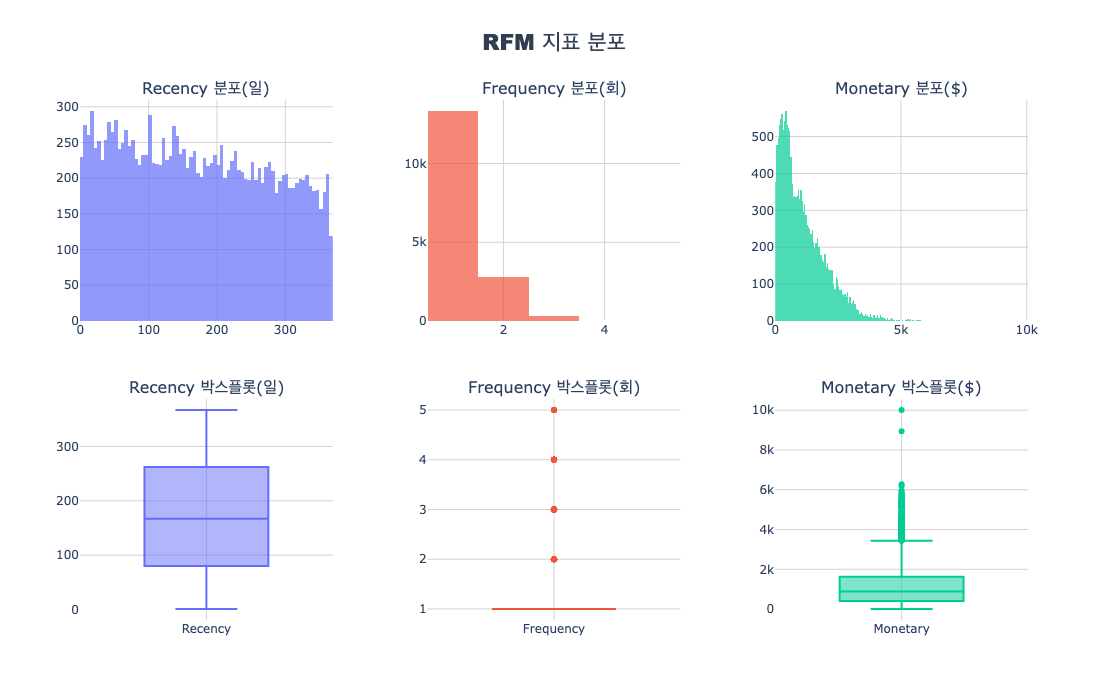

        Recency  Frequency  Monetary
count  16479.00   16479.00  16479.00
mean     172.54       1.22   1113.13
std      105.51       0.48    913.96
min        1.00       1.00      6.19
25%       80.00       1.00    405.96
50%      167.00       1.00    882.75
75%      262.00       1.00   1619.63
max      367.00       5.00  10008.87


In [13]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Recency 분포(일)', 'Frequency 분포(회)', 'Monetary 분포($)',
        'Recency 박스플롯(일)', 'Frequency 박스플롯(회)', 'Monetary 박스플롯($)'
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

metrics = ['Recency', 'Frequency', 'Monetary']
colors = ['#636EFA', '#EF553B', '#00CC96']

for i, (metric, color) in enumerate(zip(metrics, colors), 1):
    fig.add_trace(
        go.Histogram(
            x=rfm_lifetime[metric],
            marker_color=color,
            opacity=0.7,
            name=metric,
            showlegend=False
        ),
        row=1, col=i
    )
    fig.add_trace(
        go.Box(
            y=rfm_lifetime[metric],
            marker_color=color,
            name=metric,
            showlegend=False,
            boxpoints='outliers'
        ),
        row=2, col=i
    )

fig.update_layout(
    title=dict(
        text='RFM 지표 분포',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=700,
    width=1100,
    plot_bgcolor='white'
)

fig.update_xaxes(gridcolor='lightgray')
fig.update_yaxes(gridcolor='lightgray')

fig.show()

print(rfm_lifetime[['Recency', 'Frequency', 'Monetary']].describe().round(2))

## 📊 RFM 지표 점수화 (1~5점)

RFM 지표 분포를 확인한 결과, 각 지표의 특성에 맞게 점수화 방식을 다르게 적용했다.

### R (Recency) - Quantile 5등분
- 분포가 비교적 균등한 형태로, 단순 Quantile 5등분을 적용했다.
- 최근 구매일수록 높은 점수를 부여한다. (역순)

| 점수 | 구간 |
|------|------|
| 5점 | 하위 20% (가장 최근 구매) |
| 4점 | 20~40% |
| 3점 | 40~60% |
| 2점 | 60~80% |
| 1점 | 상위 20% (가장 오래된 구매) |

### F (Frequency) - 직접 구간 지정
- 전체 범위가 1~5회로 좁고, 1회 구매 고객이 전체의 80% 이상을 차지한다.
- 이는 1년치 데이터 특성상 재구매 주기가 긴 이커머스 업종의 자연스러운 분포로, 구매 횟수 자체를 기준으로 직접 구간을 지정했다.

| 점수 | 구간 |
|------|------|
| 1점 | 1회 | 
| 2점 | 2회 | 
| 3점 | 3회 | 
| 4점 | 4회 | 
| 5점 | 5회 이상 |

### M (Monetary) - 직접 구간 지정
- 오른쪽으로 긴 꼬리 형태(right-skewed)의 분포로 이상치가 존재한다.
- 25/50/75% 분위수와 IQR upper bound를 기준으로 직접 구간을 지정하여 이상치를 최고점으로 분리했다.

| 점수 | 구간 | 기준 |
|------|------|------|
| 1점 | USD 406 미만 | 하위 25% |
| 2점 | USD 406 ~ 883 | 25~50% |
| 3점 | USD 883 ~ 1,620 | 50~75% |
| 4점 | USD 1,620 ~ 3,440 | 75% ~ IQR upper bound |
| 5점 | USD 3,440 이상 | 이상치 구간 |

In [14]:
# R 점수 
rfm_lifetime['R'] = pd.qcut(
    rfm_lifetime['Recency'],
    q=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[5, 4, 3, 2, 1]
).astype(int)

# F 점수
rfm_lifetime['F'] = pd.cut(
    rfm_lifetime['Frequency'],
    bins=[0, 1, 2, 3, 4, 5],
    labels=[1, 2, 3, 4, 5]
).astype(int)

# M 점수
rfm_lifetime['M'] = pd.cut(
    rfm_lifetime['Monetary'],
    bins=[0, 406, 882, 1619, 3440, rfm_lifetime['Monetary'].max()],
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [15]:
rfm_lifetime.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M
0,CUST000001,157,1,446.48,3,1,2
1,CUST000004,196,1,583.70,3,1,2
2,CUST000006,249,1,818.42,2,1,2
3,CUST000008,53,1,2032.83,5,1,4
4,CUST000009,258,1,26.00,2,1,1


## 최적 클러스터 수 결정

KMeans 클러스터링을 수행하기 전, 최적의 클러스터 수(k)를 결정하기 위해 **Elbow Method**와 **Silhouette Score** 두 가지 방법을 함께 사용했다.  
이상치에 민감한 Recency, Frequency, Monetary 원본 수치를 그대로 사용하면 클러스터링 결과가 왜곡될 수 있기 때문에, 이상치에 덜 민감한 **RobustScaler**로 스케일링한 값을 사용했다.

- **Elbow Method**: k가 증가할수록 클러스터 내 분산(Inertia)이 감소하는데, 감소폭이 급격히 줄어드는 지점(꺾이는 지점)을 최적 k로 선택한다.
- **Silhouette Score**: 클러스터링의 품질을 평가하는 지표로, 1에 가까울수록 클러스터가 잘 나뉜 것을 의미한다. 가장 높은 점수를 보이는 k를 최적 k로 선택한다.

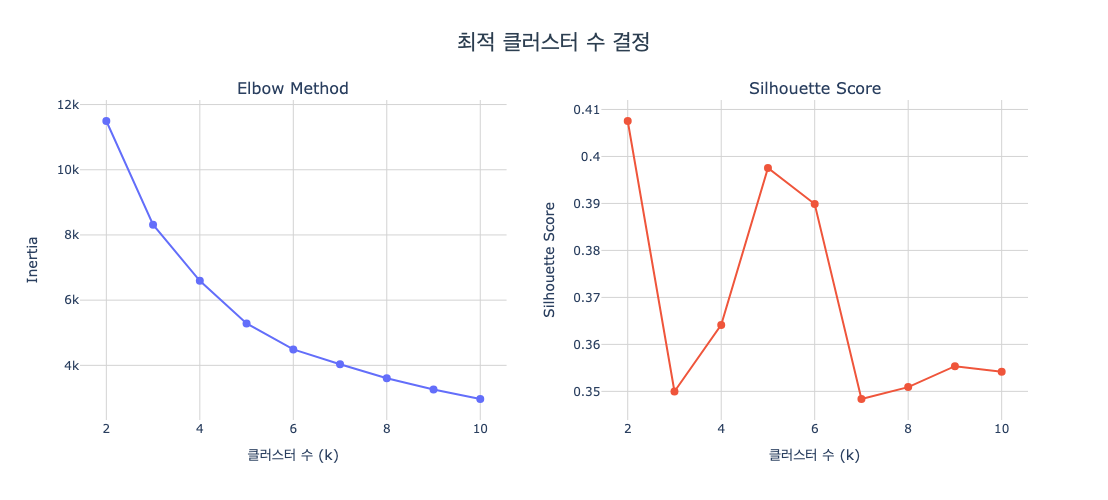

k=2: 0.4075
k=3: 0.3500
k=4: 0.3641
k=5: 0.3976
k=6: 0.3899
k=7: 0.3484
k=8: 0.3509
k=9: 0.3554
k=10: 0.3542


In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score

features = rfm_lifetime[['Recency', 'Frequency', 'Monetary']]
scaler = RobustScaler()
scaled_features = pd.DataFrame(
    scaler.fit_transform(features),
    columns=['Recency', 'Frequency', 'Monetary']
)

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, labels))

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Elbow Method', 'Silhouette Score')
)

fig.add_trace(
    go.Scatter(
        x=list(k_range), y=inertias,
        mode='lines+markers',
        marker=dict(size=8, color='#636EFA'),
        line=dict(color='#636EFA'),
        showlegend=False
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=list(k_range), y=silhouette_scores,
        mode='lines+markers',
        marker=dict(size=8, color='#EF553B'),
        line=dict(color='#EF553B'),
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(
        text='최적 클러스터 수 결정',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    width=1000,
    plot_bgcolor='white'
)

fig.update_xaxes(gridcolor='lightgray')
fig.update_yaxes(gridcolor='lightgray')
fig.update_yaxes(title_text='Inertia', row=1, col=1)
fig.update_yaxes(title_text='Silhouette Score', row=1, col=2)
fig.update_xaxes(title_text='클러스터 수 (k)', row=1, col=1)
fig.update_xaxes(title_text='클러스터 수 (k)', row=1, col=2)

fig.show()

for k, s in zip(k_range, silhouette_scores):
    print(f"k={k}: {s:.4f}")

Elbow Method는 k=4~5 구간에서 완만하게 꺾이는 형태를 보이나 명확한 최적점을 판단하기 어려웠다.
Silhouette Score는 k=2(0.41)가 가장 높았으나 두 개의 클러스터로는 고객군을 세분화하기에 지나치게 단순하다.
k=5(0.398)가 두번째로 높은 점수를 보이며, Elbow Method의 꺾임점과도 일치한다. 따라서 **k=5**를 최적 클러스터 수로 선정했다.

In [17]:
# k=5으로 KMeans 클러스터링
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm_lifetime['Cluster'] = kmeans.fit_predict(scaled_features)

# 클러스터별 RFM 평균
cluster_summary = rfm_lifetime.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(cluster_summary)
print("\n클러스터별 고객 수:")
print(rfm_lifetime['Cluster'].value_counts())

         Recency  Frequency  Monetary
Cluster                              
0          91.51       1.00    600.36
1         186.58       1.01   2014.39
2         280.30       1.01    584.34
3         113.13       2.25   3238.20
4         113.27       2.07   1316.74

클러스터별 고객 수:
Cluster
2    5199
0    5190
1    3020
4    1996
3    1074
Name: count, dtype: int64


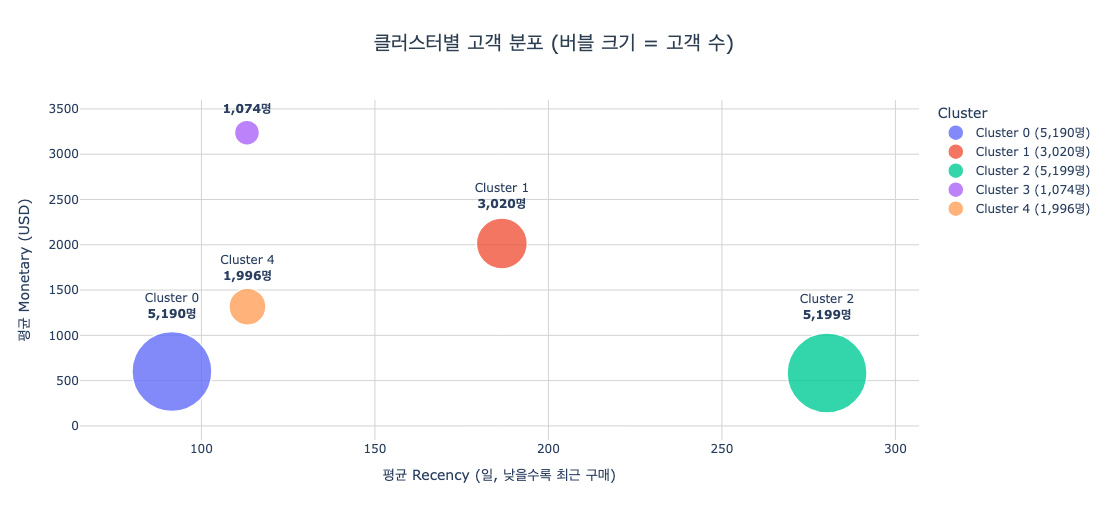

In [18]:
# 클러스터별 고객 분포 (중심점 버블, 크기 = 고객 수)
cluster_counts = rfm_lifetime['Cluster'].value_counts().sort_index()
cluster_viz = rfm_lifetime.groupby('Cluster')[['Recency', 'Monetary']].mean().round(2)
cluster_viz['Count'] = cluster_counts

colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A']

# 버블 크기 정규화 (25 ~ 80)
min_c, max_c = cluster_viz['Count'].min(), cluster_viz['Count'].max()
cluster_viz['Size'] = ((cluster_viz['Count'] - min_c) / (max_c - min_c) * 55 + 25).round(0)

fig = go.Figure()

for cluster_id in sorted(cluster_viz.index):
    row = cluster_viz.loc[cluster_id]
    fig.add_trace(go.Scatter(
        x=[row['Recency']],
        y=[row['Monetary']],
        mode='markers+text',
        marker=dict(
            size=row['Size'],
            color=colors[cluster_id],
            opacity=0.8,
            line=dict(width=1.5, color='white')
        ),
        text=[f"Cluster {cluster_id}<br><b>{int(row['Count']):,}명</b>"],
        textposition='top center',
        name=f"Cluster {cluster_id} ({int(row['Count']):,}명)",
        hovertemplate=(
            f"Cluster {cluster_id}<br>"
            "Recency: %{x:.1f}일<br>"
            "Monetary: %{y:,.0f} USD<br>"
            f"고객 수: {int(row['Count']):,}명<extra></extra>"
        )
    ))

fig.update_layout(
    title=dict(
        text='클러스터별 고객 분포 (버블 크기 = 고객 수)',
        font=dict(size=20, color='#2c3e50'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title='평균 Recency (일, 낮을수록 최근 구매)',
        gridcolor='lightgray',
        zeroline=False
    ),
    yaxis=dict(
        title='평균 Monetary (USD)',
        gridcolor='lightgray',
        zeroline=False
    ),
    plot_bgcolor='white',
    height=520,
    width=850,
    showlegend=True,
    legend=dict(title='Cluster')
)

fig.show()

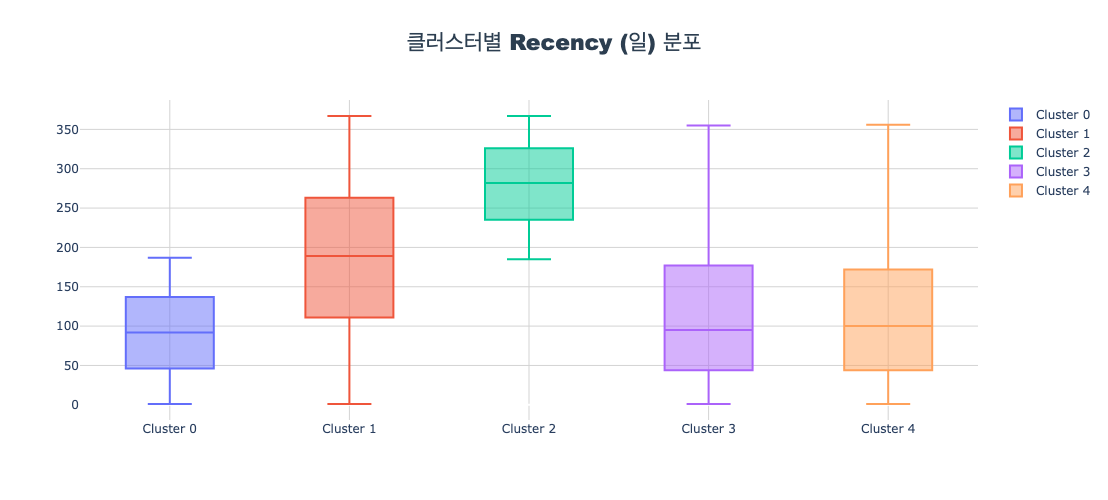

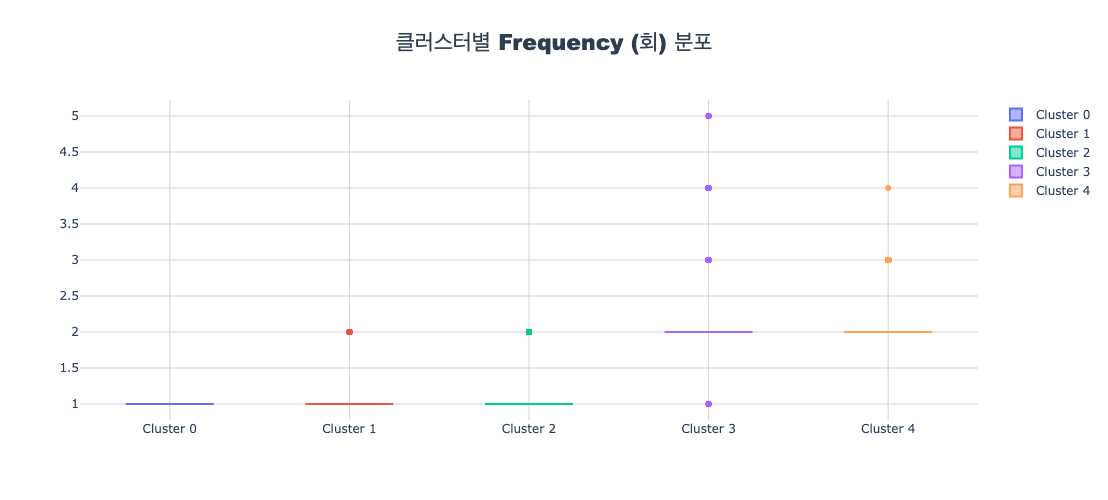

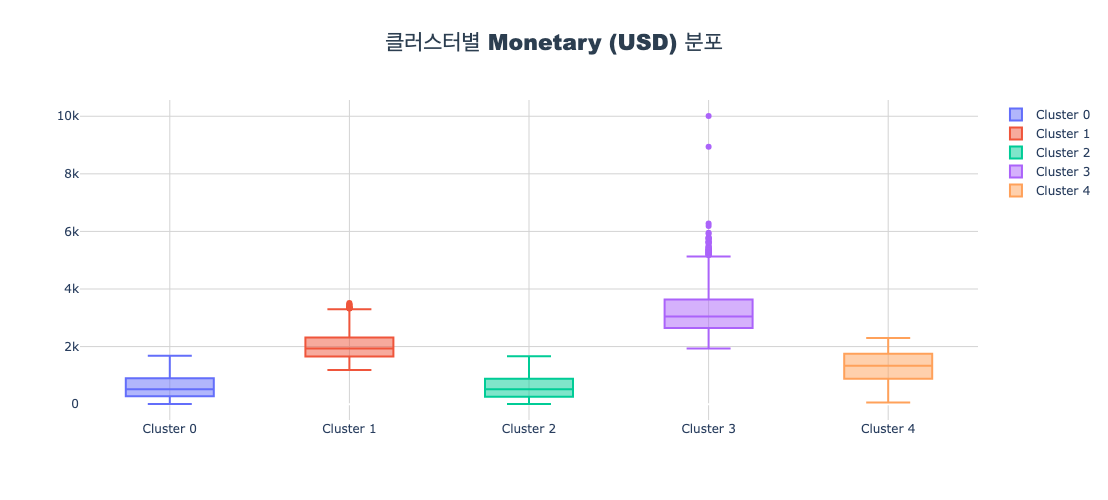

In [19]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A']
metrics = ['Recency', 'Frequency', 'Monetary']
titles = ['Recency (일)', 'Frequency (회)', 'Monetary (USD)']

for metric, title in zip(metrics, titles):
    fig = go.Figure()
    
    for j, cluster_id in enumerate(sorted(rfm_lifetime['Cluster'].unique())):
        data = rfm_lifetime[rfm_lifetime['Cluster'] == cluster_id][metric]
        fig.add_trace(
            go.Box(
                y=data,
                name=f'Cluster {cluster_id}',
                marker_color=colors[j],
                boxpoints='outliers'
            )
        )
    
    fig.update_layout(
        title=dict(
            text=f'클러스터별 {title} 분포',
            font=dict(size=22, color='#2c3e50', family='Arial Black'),
            x=0.5,
            xanchor='center'
        ),
        height=500,
        width=900,
        plot_bgcolor='white'
    )
    
    fig.update_xaxes(gridcolor='lightgray')
    fig.update_yaxes(gridcolor='lightgray')
    
    fig.show()

In [20]:
rfm_lifetime.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,Cluster
0,CUST000001,157,1,446.48,3,1,2,0
1,CUST000004,196,1,583.70,3,1,2,2
2,CUST000006,249,1,818.42,2,1,2,2
3,CUST000008,53,1,2032.83,5,1,4,1
4,CUST000009,258,1,26.00,2,1,1,2


### 클러스터 결과 해석

클러스터별 R/F/M 분포를 확인한 결과, 5개 그룹이 **최근성(R)과 구매 금액(M)** 을 기준으로 뚜렷하게 분리됨을 확인할 수 있다.

반면 구매 빈도(F)는 클러스터 간 차이가 거의 없어 **변별력이 매우 낮게** 나타났다.  
이는 분석 기간이 1년으로 한정되어 있어 대부분의 고객이 **1~2회 구매에 그치는 구조적 특성** 때문이다.  
분석 기간을 2~3년으로 늘리면 F 변별력은 높아지지만, 수년 전 구매 이력이 포함되어 **최근성(R)의 신뢰도가 희석**되는 트레이드오프가 발생한다.  
마케팅 현실성과 최근성을 우선하여 1년 기준을 유지하되, **F의 기여도가 낮다는 점은 이후 PCA 가중치에서도 수치로 확인**된다.

그러나 KMeans는 클러스터 간 **상대적 위치**만 반영할 뿐, R / F / M 각각이 단일 점수로 통합될 때의 **상대적 중요도**는 알 수 없다.  
이를 보완하기 위해 **PCA(주성분 분석)** 를 적용하여 R / F / M의 분산 기여도를 기반으로 **가중치를 데이터 기반으로 도출**한다.  
별도의 레이블 없이 데이터 구조 자체에서 가중치를 추출하므로, 클러스터 레이블에 의존하는 순환 의존성 없이 독립적인 가중치 산출이 가능하다.

## 가중치 설정하기

R / F / M 점수(1~5)에 **PCA(주성분 분석)** 를 적용하여 첫 번째 주성분(PC1)의 로딩값 절댓값을 정규화한 값을 각 지표의 가중치로 사용한다.

PC1은 R / F / M 전체의 분산을 가장 많이 설명하는 방향으로, 각 로딩값은 해당 지표가 고객 간 차이를 설명하는 데 얼마나 기여하는지를 반영한다.

| Feature | 정규화 가중치 |
|:-------:|:------------:|
| Recency   | **0.6931** |
| Frequency | **0.2116** |
| Monetary  | **0.0953** |

PC1 설명 분산 비율: **60.6%**

R(최근성)이 고객 간 분산을 가장 크게 주도하며, M(구매금액)의 기여는 상대적으로 낮게 나타났다.  
이는 1~5점 스코어 기준으로 Recency의 분산이 가장 크고, 1년 데이터 기준 대부분의 고객이 단일 구매라 **Monetary 변별력도 제한적**이기 때문으로 해석된다.

```
RFM Score = (R × 0.6931 + F × 0.2116 + M × 0.0953) / 5 × 100  →  0 ~ 100점
```

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
import numpy as np

X = rfm_lifetime[['R', 'F', 'M']]

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
pca.fit(X_scaled)

# PC1 로딩값 절댓값 정규화 → 가중치
loadings = np.abs(pca.components_[0])
weights = loadings / loadings.sum()

r_w, f_w, m_w = weights

print(f"R 가중치: {r_w:.4f}")
print(f"F 가중치: {f_w:.4f}")
print(f"M 가중치: {m_w:.4f}")
print(f"합계: {r_w + f_w + m_w:.4f}")
print(f"PC1 설명 분산 비율: {pca.explained_variance_ratio_[0]:.3f}")

R 가중치: 0.6931
F 가중치: 0.2116
M 가중치: 0.0953
합계: 1.0000
PC1 설명 분산 비율: 0.606


In [22]:
rfm_lifetime['RFM_score'] = (
    rfm_lifetime['R'] * r_w +
    rfm_lifetime['F'] * f_w +
    rfm_lifetime['M'] * m_w
) / 5 * 100

print(rfm_lifetime['RFM_score'].describe().round(2))

count    16479.00
mean        51.59
std         20.64
min         20.00
25%         33.86
50%         51.54
75%         67.72
max        100.00
Name: RFM_score, dtype: float64


In [23]:
def customer(RFM_score):
    if RFM_score <= 34:
        return 'Bronze'
    elif RFM_score <= 51:
        return 'Silver'
    elif RFM_score <= 66:
        return 'Gold'
    elif RFM_score <= 83:
        return 'Platinum'
    else:
        return 'Diamond'

rfm_lifetime['Grade'] = rfm_lifetime['RFM_score'].apply(customer)

In [24]:
# 전체 수치 확인
grade_analysis = pd.DataFrame({
    '고객수': rfm_lifetime['Grade'].value_counts(),
    '고객비중(%)': rfm_lifetime['Grade'].value_counts(normalize=True) * 100,
    '매출합계': rfm_lifetime.groupby('Grade')['Monetary'].sum(),
    '매출비중(%)': rfm_lifetime.groupby('Grade')['Monetary'].sum() / rfm_lifetime['Monetary'].sum() * 100,
    '1인당지출': rfm_lifetime.groupby('Grade')['Monetary'].mean()
}).round(2)

grade_analysis = grade_analysis.reindex(['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond'])

In [25]:
grade_analysis

,고객수,고객비중(%),매출합계,매출비중(%),1인당지출
Grade,,,,,
Bronze,4168,25.29,3254063.82,17.74,780.73
Silver,3900,23.67,3873506.25,21.12,993.21
Gold,3863,23.44,4334404.83,23.63,1122.03
Platinum,3629,22.02,4791960.41,26.12,1320.46
Diamond,919,5.58,2089402.54,11.39,2273.56


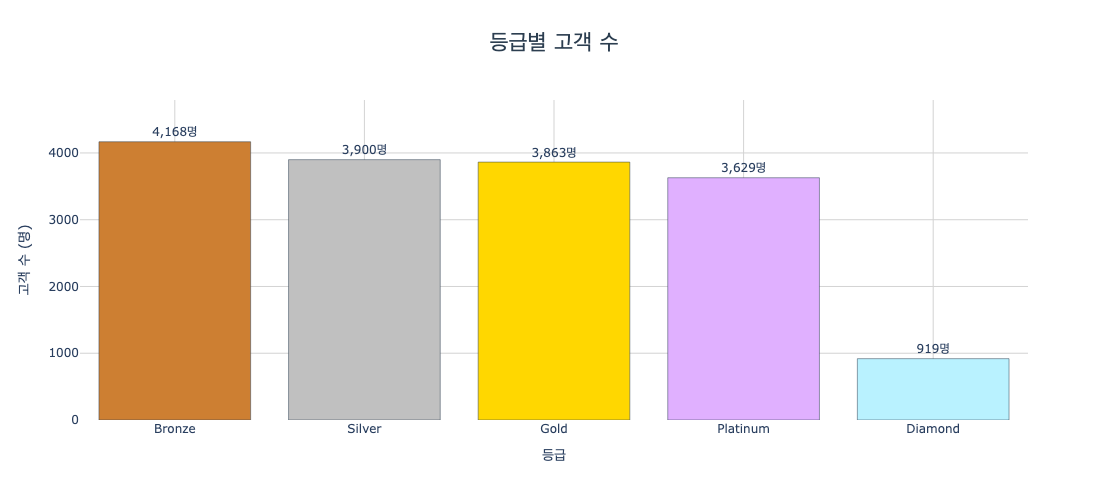

In [26]:
color_map = {
    'Bronze': '#CD7F32',
    'Silver': '#C0C0C0',
    'Gold': '#FFD700',
    'Platinum': '#E0B0FF',
    'Diamond': '#B9F2FF'
}


fig = go.Figure(go.Bar(
    x=grade_analysis.index,
    y=grade_analysis['고객수'],
    marker=dict(
        color=[color_map[g] for g in grade_analysis.index],
        line=dict(color='#2c3e50', width=0.5)
    ),
    text=grade_analysis['고객수'].apply(lambda x: f'{x:,}명'),
    textposition='outside'
))

fig.update_layout(
    title=dict(
        text='등급별 고객 수',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    width=700,
    plot_bgcolor='white'
)

fig.update_xaxes(title_text='등급', gridcolor='lightgray')
fig.update_yaxes(
    title_text='고객 수 (명)',
    gridcolor='lightgray',
    range=[0, grade_analysis['고객수'].max() * 1.15]
)

fig.show()

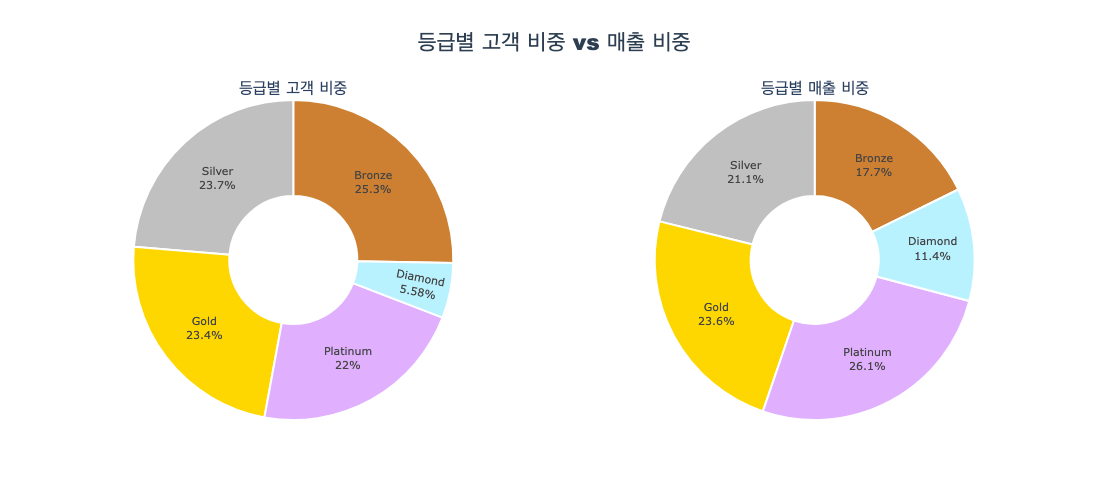

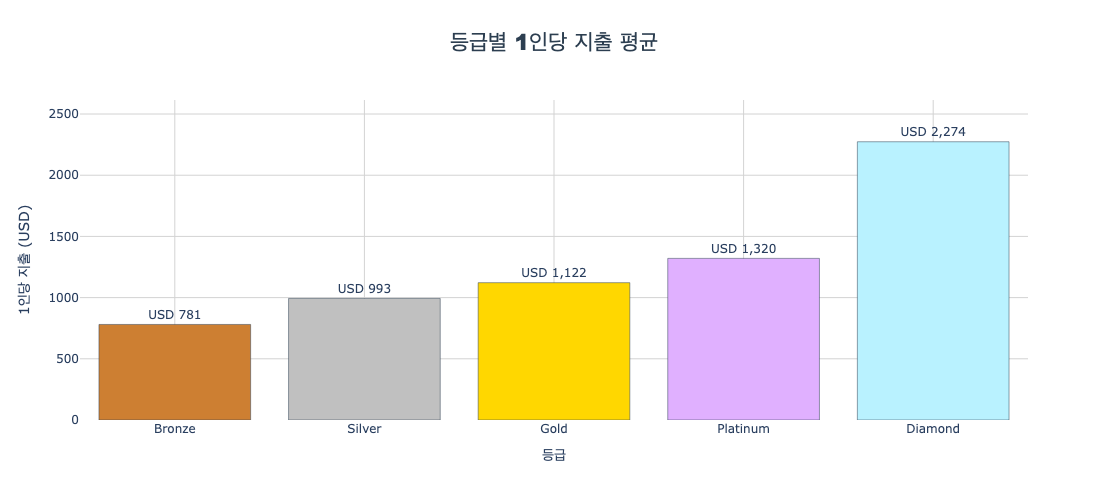

In [27]:
color_map = {
    'Bronze': '#CD7F32',
    'Silver': '#C0C0C0',
    'Gold': '#FFD700',
    'Platinum': '#E0B0FF',
    'Diamond': '#B9F2FF'
}


# 각 등급별 고객 비중 / 등급별 매출 비중 파이 차트
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['등급별 고객 비중', '등급별 매출 비중'],
    specs=[[{'type': 'pie'}, {'type': 'pie'}]]
)

for col, value_col in enumerate(['고객비중(%)', '매출비중(%)'], 1):
    fig.add_trace(
        go.Pie(
            labels=grade_analysis.index,
            values=grade_analysis[value_col],
            marker=dict(
                colors=[color_map[g] for g in grade_analysis.index],
                line=dict(color='white', width=2)
            ),
            textinfo='label+percent',
            textposition='inside',
            textfont=dict(size=11),
            showlegend=False,
            hole=0.4,
            sort=False
        ),
        row=1, col=col
    )

fig.update_layout(
    title=dict(
        text='등급별 고객 비중 vs 매출 비중',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    width=900,
    plot_bgcolor='white'
)


fig.show()


# 1인당 지출 막대차트
fig2 = go.Figure(go.Bar(
    x=grade_analysis.index,
    y=grade_analysis['1인당지출'],
    marker=dict(
        color=[color_map[g] for g in grade_analysis.index],
        line=dict(color='#2c3e50', width=0.5)
    ),
    text=grade_analysis['1인당지출'].apply(lambda x: f'USD {x:,.0f}'),
    textposition='outside'
))

fig2.update_layout(
    title=dict(
        text='등급별 1인당 지출 평균',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    width=700,
    plot_bgcolor='white'
)

fig2.update_xaxes(title_text='등급', gridcolor='lightgray')
fig2.update_yaxes(title_text='1인당 지출 (USD)', gridcolor='lightgray',
                  range=[0, grade_analysis['1인당지출'].max() * 1.15])

fig2.show()

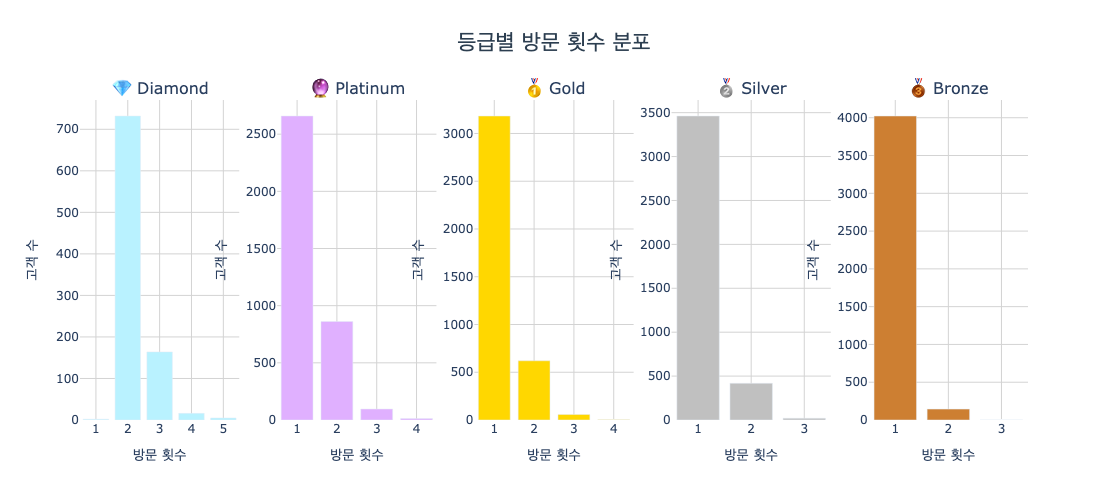

In [28]:
fig = make_subplots(
    rows=1, cols=5,
    subplot_titles=['💎 Diamond', '🔮 Platinum', '🥇 Gold', '🥈 Silver', '🥉 Bronze']
)

grades = ['Diamond', 'Platinum', 'Gold', 'Silver', 'Bronze']
colors = ['#B9F2FF', '#E0B0FF', '#FFD700', '#C0C0C0', '#CD7F32']

for i, (grade, color) in enumerate(zip(grades, colors), 1):
    data = rfm_lifetime[rfm_lifetime['Grade'] == grade]['Frequency'].value_counts().sort_index()
    fig.add_trace(
        go.Bar(
            x=data.index,
            y=data.values,
            marker_color=color,
            showlegend=False,
            name=grade
        ),
        row=1, col=i
    )

fig.update_layout(
    title=dict(
        text='등급별 방문 횟수 분포',
        font=dict(size=22, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    width=1200,
    plot_bgcolor='white'
)

fig.update_xaxes(
    tickvals=[1, 2, 3, 4, 5],
    title_text='방문 횟수',
    gridcolor='lightgray'
)
fig.update_yaxes(
    title_text='고객 수',
    gridcolor='lightgray'
)

fig.show()

In [29]:
# 각 등급별 고객의 재방문율 계산
for grade in ['Diamond', 'Platinum', 'Gold', 'Silver', 'Bronze']:
    data = rfm_lifetime[rfm_lifetime['Grade'] == grade]['Frequency']
    revisit = (data >= 2).sum()
    total = len(data)
    print(f"{grade}: {revisit/total*100:.1f}% ({revisit}/{total})")

Diamond: 99.8% (917/919)
Platinum: 26.7% (970/3629)
Gold: 17.6% (680/3863)
Silver: 11.2% (438/3900)
Bronze: 3.5% (145/4168)


### 분석 결과 DB 적재

이후 등급별 세부 분석 노트북에서 `orders_info`와 JOIN하여 활용할 수 있도록  
CustomerID와 Grade 두 컬럼만 추출하여 MySQL `rfm_result` 테이블에 저장한다.

| 컬럼 | 설명 |
|------|------|
| CustomerID | 고객 식별자 |
| Grade | 등급 (Bronze / Silver / Gold / Platinum / Diamond) |

> R·F·M 원본 수치는 저장하지 않으며, 필요 시 `orders_info` 윈도우 함수로 직접 계산한다.

In [30]:
# RFM 분석 결과 등급 정보를 MySQL에 적재
rfm_save = rfm_lifetime[['CustomerID', 'Grade']]
rfm_save.to_sql(
    name='rfm_result',
    con=engine,
    if_exists='replace',
    index=False
)

16479

## 📊 고객 등급별 분석 결과

**💎 Diamond (고충성 고가치 고객군)**

고객 비중은 5.58%(919명)으로 가장 적지만 1인당 지출이 USD 2,274로 압도적으로 높다.  
재방문율 99.8%로 사실상 전원이 재구매 경험이 있는 핵심 충성 고객군이다.  
소수이지만 이탈 시 매출 타격이 크므로 장기 유지 전략이 필요하다.

---

**🔮 Platinum (매출 기여 1위 고객군)**

고객 비중 22.02%(3,629명)로 매출 기여도가 26.12%로 전체 1위를 차지한다.  
재방문율(26.7%)은 Diamond 다음으로 높아 유지와 Diamond 전환이 핵심 과제다.

---

**🥇 Gold (성장 가능 고객군)**

고객 비중(23.44%)과 매출 기여도(23.63%)가 Platinum에 근접한 수준이다.  
1인당 지출(USD 1,122)과 Platinum(USD 1,320)의 차이(USD 198)를 줄이는 것이 Platinum 전환의 핵심이다.

---

**🥈 Silver (재구매 유도 고객군)**

전체 고객의 23.67%(3,900명)로 매출 기여도는 21.12%에 그친다.  
1인당 지출이 USD 993로 Gold(USD 1,122)와의 격차가 크지 않아 구매 빈도 증가만으로도 등급 상승 가능성이 있다.

---

**🥉 Bronze (이탈 위험 고객군)**

재방문율이 3.5%로 전체 등급 중 가장 낮다.  
고객 비중(25.29%)은 가장 크지만 매출 기여도(17.74%)는 낮아, 첫 재구매 유도를 통한 Silver 전환이 핵심 과제다.

---

## 다음 분석 방향

위 분석 결과를 바탕으로 두 가지 관점에서 핵심 그룹을 도출했다.  
재방문율 기준으로는 **Diamond(99.8%)와 Platinum(26.7%)** 이, 매출 기여도 기준으로는 **Platinum(26.12%)과 Gold(23.63%)** 이 핵심 그룹이다.  
두 관점 모두에 속하는 **Platinum이 가장 중요한 등급**임을 확인할 수 있으며, 이를 바탕으로 3개 그룹으로 나누어 세부 분석을 진행한다.

| 분석 그룹 | 핵심 문제 |
|----------|---------|
| 💎 Diamond + 🔮 Platinum | 언제 재구매하는가? |
| 🔮 Platinum + 🥇 Gold | 왜 더 안 사는가? |
| 🥈 Silver + 🥉 Bronze | 왜 재구매를 안 하는가? |